In [5]:
from tensorflow.keras.datasets import mnist

(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

import pandas as pd

data = pd.DataFrame(X_train.reshape(60000, 784))

# print(data.head())

X_train_full = X_train
Y_train_full = Y_train

# Validation set
X_val = X_train_full[:10000]
Y_val = Y_train_full[:10000]

# Training set
X_train = X_train_full[10000:]
Y_train = Y_train_full[10000:]

# Flatten 28x28 images into 784
X_train = X_train.reshape(X_train.shape[0], 784)
X_val = X_val.reshape(X_val.shape[0], 784)

# Transpose so each image becomes a column
X_train = X_train.T
X_val = X_val.T

# Normalize
X_train = X_train / 255.0
X_val = X_val / 255.0

# print("X_train:", X_train.shape)
# print("Y_train:", Y_train.shape)

print("X_val:", X_val.shape)
print("Y_val:", Y_val.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)
X_val: (784, 10000)
Y_val: (10000,)


In [6]:
print(X_train.min())
print(X_train.max())
print(X_train.shape)
print(Y_train.shape)

0.0
1.0
(784, 50000)
(50000,)


In [7]:
import numpy as np

def init_params():
    W1 = np.random.randn(256, 784) * np.sqrt(2 / 784)
    b1 = np.zeros((256, 1))
    W2 = np.random.randn(10, 256 ) * np.sqrt(2 / 256)
    b2 = np.zeros((10, 1))
    return W1,b1,W2,b2

def relu(Z):
    return np.maximum(0, Z)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)
    return np.exp(Z) / np.sum(np.exp(Z),axis=0, keepdims=True)

def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) + b1
    A1 = relu(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size,Y.max()+ 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_relu(Z):
    return Z > 0 
    
def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_y = one_hot(Y)
    dz2 = A2 - one_hot_y
    dw2 = 1/m * dz2.dot(A1.T)
    db2 = 1/m * np.sum(dz2, axis=1, keepdims=True)
    dz1 = W2.T.dot(dz2) * deriv_relu(Z1)
    dw1 = 1/m * dz1.dot(X.T)
    db1 = 1/m * np.sum(dz1, axis=1, keepdims=True)
    return dw1, db1, dw2, db2

def update_params(W1,b1,W2,b2, dw1, db1, dw2, db2, alpha):
    W1 = W1 - alpha * dw1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dw2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

def get_pred(A):
    return np.argmax(A, 0)

def get_acc(pred, Y):
    return np.sum(pred == Y) / Y.size

def get_loss(A2, Y):
    m = Y.size

    one_hot_Y = one_hot(Y)

    epsilon = 1e-10

    loss = -np.sum(
        one_hot_Y * np.log(A2 + epsilon)
    ) / m

    return loss

def gradient_descent(X, Y, alpha, iterations):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        #forward propagation
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        #backward propagation
        dw1, db1, dw2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        #weights updation
        W1, b1, W2, b2 = update_params(W1,b1,W2,b2, dw1, db1, dw2, db2, alpha)
        if i % 10 == 0:
            print("iteration:",i)
            print("Accuracy:", get_acc(get_pred(A2),Y))
            print("Loss:", get_loss(A2,Y))
    return W1, b1, W2, b2


# W1 , b1, W2, b2 = gradient_descent(X_train, Y_train, 0.2, 200)


In [8]:
W1 , b1, W2, b2 = gradient_descent(X_train, Y_train, 0.1, 500)


iteration: 0
Accuracy: 0.08006
Loss: 2.3771871393091937
iteration: 10
Accuracy: 0.71014
Loss: 1.4863746452196758
iteration: 20
Accuracy: 0.79264
Loss: 1.0372478805965564
iteration: 30
Accuracy: 0.82494
Loss: 0.8139649594279534
iteration: 40
Accuracy: 0.84308
Loss: 0.6902183683108443
iteration: 50
Accuracy: 0.8552
Loss: 0.6127665214473734
iteration: 60
Accuracy: 0.86332
Loss: 0.5597268484117183
iteration: 70
Accuracy: 0.86982
Loss: 0.5209802830857235
iteration: 80
Accuracy: 0.87554
Loss: 0.4913185730660278
iteration: 90
Accuracy: 0.88036
Loss: 0.46777153312708314
iteration: 100
Accuracy: 0.88384
Loss: 0.448559321244216
iteration: 110
Accuracy: 0.88712
Loss: 0.4325203778972432
iteration: 120
Accuracy: 0.88986
Loss: 0.4188739591357957
iteration: 130
Accuracy: 0.89234
Loss: 0.4070850071755749
iteration: 140
Accuracy: 0.89416
Loss: 0.39676147958346475
iteration: 150
Accuracy: 0.8962
Loss: 0.3876110534330722
iteration: 160
Accuracy: 0.89782
Loss: 0.37942173022797565
iteration: 170
Accuracy: 

In [11]:
Z1_val, A1_val, Z2_val, A2_val = forward_prop(W1, b1, W2, b2, X_val)

A2_pred = get_pred(A2_val)

val_acc = get_acc(A2_pred, Y_val)

print("Accuracy:", val_acc)


Accuracy: 0.9256


In [13]:
# Flatten 28x28 images into 784
X_test = X_test.reshape(X_test.shape[0], 784)

# Transpose so each image becomes a column
X_test = X_test.T


# Normalize
X_test = X_test / 255.0

# print("X_train:", X_train.shape)
# print("Y_train:", Y_train.shape)

print("X_test:", X_test.shape)
print("Y_test:", Y_test.shape)



X_test: (784, 10000)
Y_test: (10000,)


In [14]:
Z1_test, A1_test, Z2_test, A2_test = forward_prop(W1, b1, W2, b2, X_test)

X_test_pred = get_pred(A2_test)

X_test_pred_acc = get_acc(X_test_pred, Y_test)

print("Accuracy:", X_test_pred_acc)

Accuracy: 0.9279


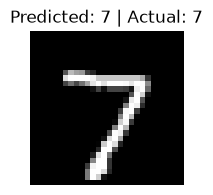

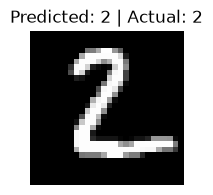

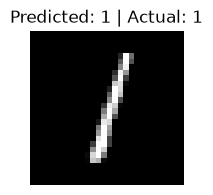

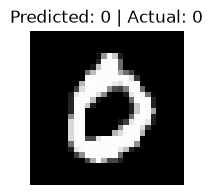

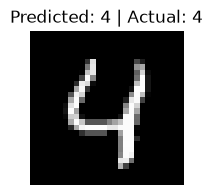

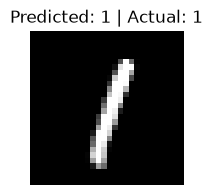

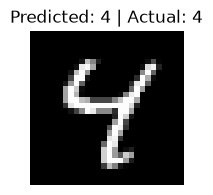

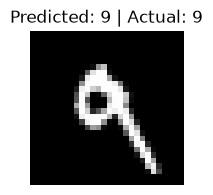

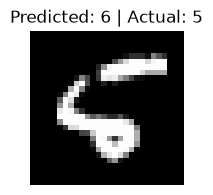

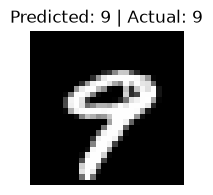

In [15]:
import matplotlib.pyplot as plt

for i in range(10):

    plt.figure(figsize=(2, 2))

    plt.imshow(
        X_test[:, i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Predicted: {X_test_pred[i]} | Actual: {Y_test[i]}"
    )

    plt.axis("off")
    plt.show()

In [16]:
wrong = np.where(X_test_pred != Y_test)[0]

print("Number of wrong predictions:", len(wrong))

Number of wrong predictions: 721


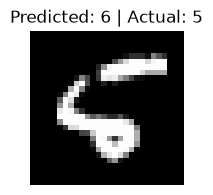

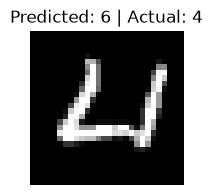

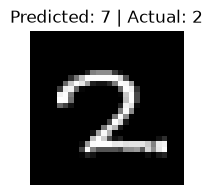

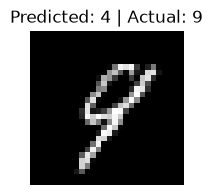

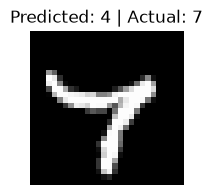

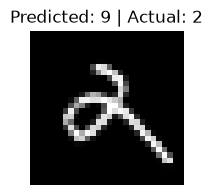

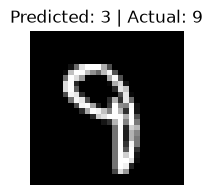

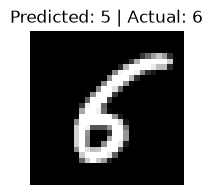

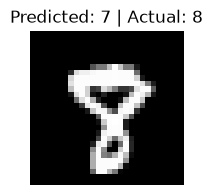

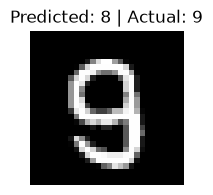

In [17]:
for i in wrong[:10]:

    plt.figure(figsize=(2, 2))

    plt.imshow(
        X_test[:, i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Predicted: {X_test_pred[i]} | Actual: {Y_test[i]}"
    )

    plt.axis("off")
    plt.show()

In [19]:
conf_matrix = np.zeros((10, 10), dtype=int)

for actual, predicted in zip(Y_test, X_test_pred):
    conf_matrix[actual, predicted] += 1

print(conf_matrix)

[[ 957    0    3    2    0    4   10    1    3    0]
 [   0 1112    2    2    0    2    4    2   11    0]
 [   9    4  924   13   14    1   13   14   33    7]
 [   3    0   16  939    0   17    1   12   13    9]
 [   1    2    3    1  916    0   12    2    6   39]
 [  10    3    4   34   10  784   16    6   17    8]
 [   9    3    4    1   13   14  910    2    2    0]
 [   5   11   20    7    7    0    0  947    3   28]
 [   7    5    7   19    9   19   11   11  877    9]
 [  12    6    2   12   36    6    1   17    4  913]]


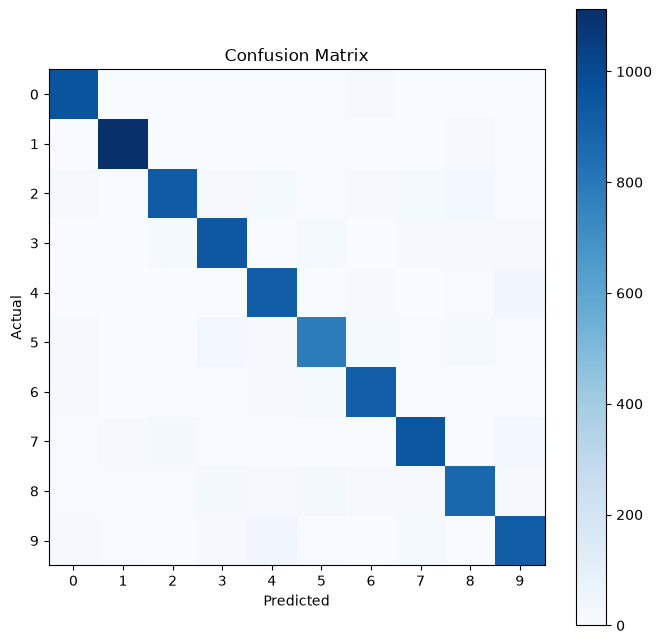

In [20]:
plt.figure(figsize=(8, 8))

plt.imshow(conf_matrix, cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(np.arange(10))
plt.yticks(np.arange(10))

plt.show()